Stochastic Variational Bayes - example nonlinear model
==============================================

This notebook implements stochastic variational Bayes for a nonlinear model. The model we will use is a bi-exponential model, i.e. we will assume our data reflects a time-dependent signal of the following form:

$$S_{true}(t) = A_1 e^{-R_1t} + A_2 e^{-R_2t}$$

However the actual time dependent signal $S(t)$ will be affected by additive Gaussian noise, so will have the distribution:

$$P(S(t)) = \frac{\sqrt{\beta}}{\sqrt{2\pi}} \exp{\bigg(-\frac{\beta}{2} (S(t) - S_{true}(t))^2}\bigg)$$

Given $S(t)$ our aim will be to infer the values of $A_1$, $A_2$, $R_1$, $R_2$ and $\beta$.

Here's how we can generate some sample data from this model in Python:

In [1]:
import numpy as np
from tqdm.notebook import tqdm_notebook
from matplotlib import pyplot as plt
import torch

%matplotlib inline
# Ground truth parameters
# We infer the precision, BETA, but it is useful to
# derive the variance and standard deviation from it
A1_TRUTH = 10.0
A2_TRUTH = 10.0
R1_TRUTH = 10.0
R2_TRUTH = 1.0
BETA_TRUTH = 0.1
VAR_TRUTH = 1/BETA_TRUTH
STD_TRUTH = np.sqrt(VAR_TRUTH)

# Observed data samples are generated by Numpy from the ground truth
# Gaussian distribution. Reducing the number of samples should make
# the inference less 'confident' - i.e. the output variances for
# MU and BETA will increase
N = 100
T = np.linspace(0, 5, N)


DATA_CLEAN = A1_TRUTH * np.exp(-R1_TRUTH * T) + A2_TRUTH * np.exp(-R2_TRUTH*T)
DATA = DATA_CLEAN + np.random.normal(0, STD_TRUTH, [N])
print("Data samples are:")
print(DATA)

Data samples are:
[19.99271167 17.18797125  9.82278249 13.42916035  7.4697979   4.19128142
  8.05509503  1.18435256  4.45630119  7.80792486  1.68521238  5.88134221
  6.74068058  6.50987174  9.90075459  7.37973681  6.36934499 -2.88944288
  7.42649517  4.8539336  -3.51011805  9.03172033  3.16101003  0.04651111
  3.52537112  1.96162878  0.50245166  0.69098994  1.72207236  2.85587939
  0.6191525   1.90753354  1.37326273 -2.52179217 -2.29338212  1.34052057
  7.00568889  1.9351049   6.61245909  3.67471708  8.22532743  3.88500215
  4.186603   -2.40612166 -3.27481723  1.7730508   2.73763447  3.96337703
 -1.61071775 -0.85171523  0.74239726  3.83935247  2.17735663  2.95844354
  1.11216948  5.76015034 -0.88161254  4.19262308 -1.98401093 -1.6013146
  2.14231753  0.94850214  4.75540997  2.136449    3.93998206 -0.79287115
 -4.15795336  4.97166475 -8.28312431  3.72447456  6.07108454 -0.42848102
  2.18947782  0.63518329  0.15141407 -1.23245703  1.18919695  2.68897554
 -0.40008588  7.07434192 -1.851984

We can plot this data to illustrate the true signal (green line) and the measured data (red crosses):

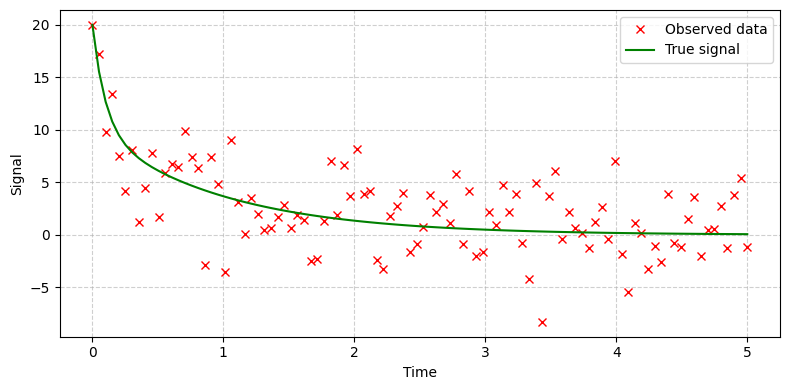

In [2]:
plt.figure(figsize=(8,4))
plt.xlabel("Time")
plt.ylabel("Signal")
plt.plot(T, DATA, "rx", label="Observed data")
plt.plot(T, DATA_CLEAN, "g", label="True signal")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

As with the single Gaussian example we will use a multivariate normal distribution as our prior and approximate posterior distributions. 

One difference here is that we will choose to infer the log of the decay rate parameters $R_1$ and $R_2$. This is because if these parameters are allowed to become negative the model prediction will become an exponential growth and can easily lead to numerical errors.

We will still choose our priors to be relatively uninformative as follows:


In [3]:
a0 = 13.0
v0 = 10.0
r0_latent = np.log(2.0)
u0 = 10.0
b0_latent = -np.log(1.0**2)
w0 = 10.0
print("Priors: Amplitude mean=%.2f, variance=%.2f" % (a0, v0))
print("        Log decay rate mean=%.2f, variance=%.2f" % (r0_latent, u0))
print("        Log noise variance mean=%.2f, variance=%.2f" % (b0_latent, w0))

Priors: Amplitude mean=13.00, variance=10.00
        Log decay rate mean=0.69, variance=10.00
        Log noise variance mean=-0.00, variance=10.00


The posterior will be defined in the same way as for the single Gaussian example, however we need to account for the increased number of parameters we are inferring. We will initialize the posterior with the prior values but with reduced initial variance to prevent problems with generating a representative posterior sample. Remember that the decay rates (and the noise) are being inferred as their log-values so the prior mean of 0 translates into a value of 1.

The code to generate a posterior sample is unchanged except for the number of parameters.

In calculating the reconstruction cost we need to calculate the log likelihood of the data given a set of model parameters. We do this by observing that any difference between the biexponential model prediction (given these parameters) and the actual noisy data must be a result of the Gaussian noise - hence the likelihood is simply the likelihood of drawing these differences from the Gaussian noise distribution:

$$\log P(\textbf{y} | A_1; A_2; r_1; r_2; \beta) = \frac{1}{2} \bigg( N \log \beta - \sum{\frac{(y_n - M_n)^2}{\beta}}\bigg)$$

Here $M_n$ is the model prediction for the nth data point which is calculated by evaluating the biexponential model for the given parameters $A_1$, $A_2$, $r_1$ and $r_2$.

For the latent loss we will again use the analytic expression for the K-L divergence of two MVN distributions with a slight modification to the previous code to account for the different number of parameters (5 vs 2)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

# Number of parameters - 4 for the biexponential + noise
NUM_PARAMS = 4 + 1

data = torch.tensor(DATA, dtype=dtype, device=device)  # shape [N]
prior_means = torch.tensor([a0, r0_latent, a0, r0_latent, b0_latent], dtype=dtype, device=device)  # shape [NUM_PARAMS]
prior_covariance = torch.diag(torch.tensor([v0, u0, v0, u0, w0], dtype=dtype, device=device))  # [P,P]

post_means_init = prior_means.clone()
post_covariance_init = np.identity(NUM_PARAMS, dtype=np.float32)  # [P,P]

# Trainable variational parameters
chol_off_diag = torch.nn.Parameter(
    torch.zeros_like(torch.tensor(post_covariance_init, dtype=dtype, device=device))
)

chol_log_diag = torch.nn.Parameter(
    torch.log(torch.diag(torch.tensor(post_covariance_init, dtype=dtype, device=device)))
)  # [P]

post_means = torch.nn.Parameter(post_means_init)  # [P]

t = torch.tensor(T, dtype=dtype, device=device).reshape(1, -1)  # [1, N]

def cost_fun():
    # Build Cholesky factor for posterior covariance
    # chol_diag = diag(sqrt(exp(chol_log_diag)))
    chol_diag = torch.diag(torch.sqrt(torch.exp(chol_log_diag)))  # [P,P]

    # lower triangle (including diag) of chol_off_diag
    tril_off = torch.tril(chol_off_diag, diagonal=-1)  # [P,P]

    # L = chol_diag + tril_off
    post_covariance_chol = chol_diag + tril_off  # [P,P]

    post_covariance = post_covariance_chol @ post_covariance_chol.T  # [P,P]

    S = 10
    N = data.shape[0]

    # eps ~ N(0, I) 
    eps = torch.randn((NUM_PARAMS, S), dtype=dtype, device=device)

    samples = post_means.view(NUM_PARAMS, 1).expand(NUM_PARAMS, S)

    # post_samples = samples + L @ eps
    post_samples = samples + (post_covariance_chol @ eps)  # [P,S]

    a1 = post_samples[0].reshape(-1, 1)                    # [S,1]
    r1 = torch.exp(post_samples[1].reshape(-1, 1))         # [S,1]
    a2 = post_samples[2].reshape(-1, 1)                    # [S,1]
    r2 = torch.exp(post_samples[3].reshape(-1, 1))         # [S,1]

    log_noise_var = -post_samples[4]                       # [S]
    noise_var = torch.exp(log_noise_var)                   # [S]

    prediction = a1 * torch.exp(-r1 * t) + a2 * torch.exp(-r2 * t)  # [S,N]

    diff = data.view(1, -1) - prediction                   # [S,N]

    sum_square_diff = torch.sum(diff * diff, dim=1)

    log_likelihood = 0.5 * (
        -log_noise_var * torch.tensor(float(N), device=device, dtype=dtype)
        - (sum_square_diff / noise_var)
    )

    reconstr_loss = -torch.mean(log_likelihood) 

    # KL term (latent_loss)
    C = post_covariance
    C0 = prior_covariance
    C0_inv = torch.linalg.inv(C0)

    m_minus_m0 = (post_means - prior_means).reshape(-1, 1)  # [P,1]
    m_minus_m0_T = (post_means - prior_means).reshape(1, -1)  # [1,P]

    term1 = torch.trace(C0_inv @ C)

    
    signC, logdetC = torch.linalg.slogdet(C)
    signC0, logdetC0 = torch.linalg.slogdet(C0)
    term2 = -(logdetC - logdetC0)

    term3 = -NUM_PARAMS
    term4 = (m_minus_m0_T @ C0_inv @ m_minus_m0).squeeze()  # scalar

    latent_loss = 0.5 * (term1 + term2 + term3 + term4)

    cost = reconstr_loss + latent_loss
    return cost

Finally we ask PyTorch to minimise the total cost iteratively:

In [5]:
optimizer = torch.optim.Adam([post_means, chol_log_diag, chol_off_diag], lr=1e-2)

cost_history = []
for epoch in tqdm_notebook(range(5000), desc="Epoch:"):
    optimizer.zero_grad()
    loss = cost_fun()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(epoch, float(loss.detach().cpu()))
    cost_history.append(loss.detach().cpu().numpy())

Epoch::   0%|          | 0/5000 [00:00<?, ?it/s]

0 3486.273193359375
100 384.8691711425781
200 405.76275634765625
300 261.5791015625
400 266.14776611328125
500 223.9779815673828
600 240.81907653808594
700 192.94764709472656
800 199.91261291503906
900 193.83106994628906
1000 184.41412353515625
1100 186.1901092529297
1200 186.1796112060547
1300 186.86888122558594
1400 187.4637908935547
1500 190.95046997070312
1600 187.93373107910156
1700 185.89462280273438
1800 184.83612060546875
1900 184.58670043945312
2000 182.9406280517578
2100 178.97987365722656
2200 185.68577575683594
2300 184.60289001464844
2400 182.09088134765625
2500 185.0360565185547
2600 182.7014923095703
2700 192.34254455566406
2800 183.1199493408203
2900 179.6564178466797
3000 178.2908935546875
3100 178.7104949951172
3200 178.7132568359375
3300 182.49075317382812
3400 180.8131561279297
3500 181.85890197753906
3600 179.86129760742188
3700 181.88832092285156
3800 185.18650817871094
3900 179.5806884765625
4000 184.67532348632812
4100 179.42825317382812
4200 179.9794921875
4300

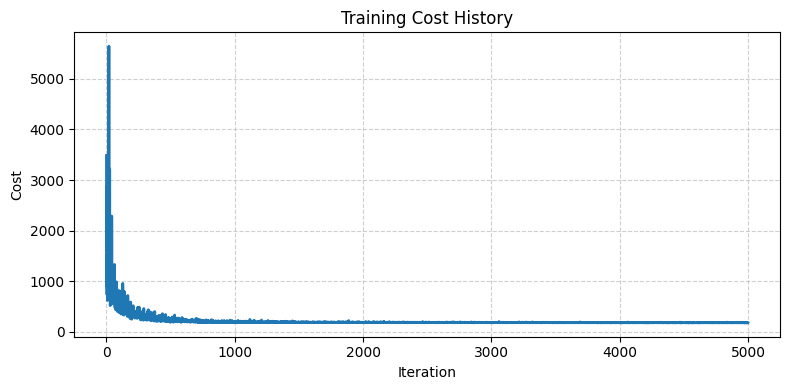

In [6]:
import matplotlib.pyplot as plt
import numpy as np


# Cost history plot
plt.figure(figsize=(8, 4))
plt.plot(cost_history, linewidth=2)
# plt.ylim(0, 500)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Training Cost History")

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

These are the prediction estimates for the parameters

In [7]:
final_means = post_means

# chol_diag = diag(sqrt(exp(chol_log_diag)))
chol_diag = torch.diag(torch.sqrt(torch.exp(chol_log_diag)))
post_covariance_chol = chol_diag + torch.tril(chol_off_diag)

# post_covariance = L^T L
post_covariance = post_covariance_chol.T @ post_covariance_chol

final_covariance = post_covariance

m = final_means.detach().cpu()
C = final_covariance.detach().cpu()

print("Estimate for amp1: %.5f (variance: %.5f)" % (m[0].item(), C[0, 0].item()))
print("Estimate for amp2: %.6f (variance: %.6f)" % (m[2].item(), C[2, 2].item()))
print("Estimate for r1: %.5f" % (torch.exp(m[1]).item(),))
print("Estimate for r2: %.5f" % (torch.exp(m[3]).item(),))
print("Estimate for beta (noise): %.5f" % (torch.exp(-m[4]).item(),))

Estimate for amp1: 9.87997 (variance: 5.99786)
Estimate for amp2: 9.572842 (variance: 4.339914)
Estimate for r1: 1.88405
Estimate for r2: 3.78189
Estimate for beta (noise): 11.51373


Let's look at the correlation matrix for the posterior distribution

In [8]:
C = post_covariance.detach().cpu()
std = torch.sqrt(torch.diag(C))
corr = C / (std[:, None] * std[None, :])
print(corr)

tensor([[ 1.0000e+00,  5.2358e-01, -4.9501e-01, -1.8287e-01, -9.8798e-03],
        [ 5.2358e-01,  1.0000e+00, -8.4353e-01, -5.7042e-01, -4.7980e-03],
        [-4.9501e-01, -8.4353e-01,  1.0000e+00,  2.1234e-01, -7.3170e-03],
        [-1.8287e-01, -5.7042e-01,  2.1234e-01,  1.0000e+00,  6.8588e-04],
        [-9.8798e-03, -4.7980e-03, -7.3170e-03,  6.8588e-04,  1.0000e+00]])


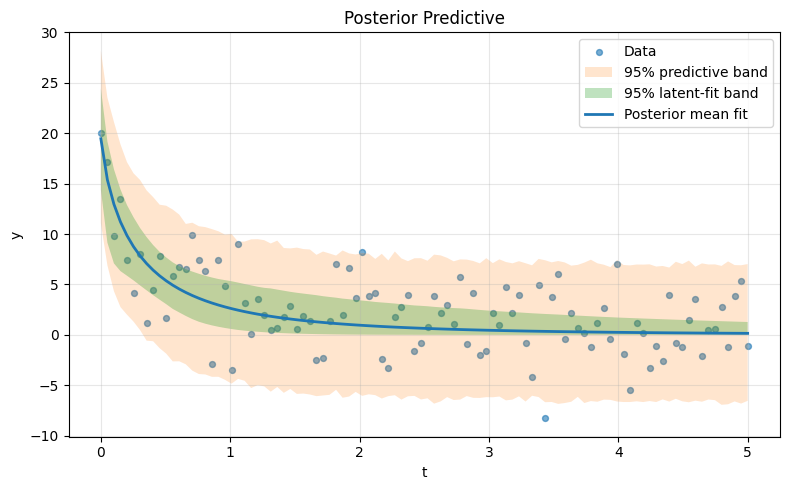

In [9]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def sample_posterior_predictive(
    T,
    post_means,
    chol_log_diag,
    chol_off_diag,
    num_samples=1000,
    device=None,
    dtype=torch.float32,
):
    if device is None:
        device = post_means.device

    T_t = torch.as_tensor(T, dtype=dtype, device=device).reshape(1, -1)

    # Build Cholesky factor L
    L_diag = torch.diag(torch.exp(0.5 * chol_log_diag))
    L_off = torch.tril(chol_off_diag, diagonal=-1)
    L = L_diag + L_off

    # Sample latent parameters: [a1, log r1, a2, log r2, -log noise_var]
    eps = torch.randn((post_means.numel(), num_samples), dtype=dtype, device=device)
    theta = post_means[:, None] + L @ eps  # [5, S]

    a1 = theta[0][:, None]                 # [S,1]
    r1 = torch.exp(theta[1])[:, None]      # [S,1]
    a2 = theta[2][:, None]                 # [S,1]
    r2 = torch.exp(theta[3])[:, None]      # [S,1]

    log_noise_var = -theta[4]              # [S]
    noise_std = torch.exp(0.5 * log_noise_var)[:, None]  # [S,1]

    mean_curve = a1 * torch.exp(-r1 * T_t) + a2 * torch.exp(-r2 * T_t)  # [S,N]

    # Posterior predictive includes observation noise
    y_pred = mean_curve + noise_std * torch.randn_like(mean_curve)

    return {
        "mean_curve_samples": mean_curve,
        "predictive_samples": y_pred,
    }


@torch.no_grad()
def plot_posterior_predictive(
    T,
    DATA,
    post_means,
    chol_log_diag,
    chol_off_diag,
    num_samples=2000,
    ci=0.95,
):
    out = sample_posterior_predictive(
        T=T,
        post_means=post_means,
        chol_log_diag=chol_log_diag,
        chol_off_diag=chol_off_diag,
        num_samples=num_samples,
        device=post_means.device,
        dtype=post_means.dtype,
    )

    T_cpu = torch.as_tensor(T).detach().cpu().numpy()
    data_cpu = torch.as_tensor(DATA).detach().cpu().numpy()

    mean_curve = out["mean_curve_samples"]
    y_pred = out["predictive_samples"]

    alpha = 1.0 - ci
    q_lo = alpha / 2.0
    q_hi = 1.0 - alpha / 2.0

    # Latent function uncertainty band
    mean_fit = mean_curve.mean(dim=0).detach().cpu().numpy()
    fit_lo = torch.quantile(mean_curve, q_lo, dim=0).detach().cpu().numpy()
    fit_hi = torch.quantile(mean_curve, q_hi, dim=0).detach().cpu().numpy()

    # Full predictive uncertainty band
    pred_lo = torch.quantile(y_pred, q_lo, dim=0).detach().cpu().numpy()
    pred_hi = torch.quantile(y_pred, q_hi, dim=0).detach().cpu().numpy()

    plt.figure(figsize=(8, 5))
    plt.scatter(T_cpu, data_cpu, s=18, alpha=0.6, label="Data")
    plt.fill_between(T_cpu, pred_lo, pred_hi, alpha=0.2, label=f"{int(ci*100)}% predictive band")
    plt.fill_between(T_cpu, fit_lo, fit_hi, alpha=0.3, label=f"{int(ci*100)}% latent-fit band")
    plt.plot(T_cpu, mean_fit, linewidth=2, label="Posterior mean fit")

    plt.xlabel("t")
    plt.ylabel("y")
    plt.title("Posterior Predictive")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# usage
plot_posterior_predictive(
    T=T,
    DATA=DATA,
    post_means=post_means,
    chol_log_diag=chol_log_diag,
    chol_off_diag=chol_off_diag,
    num_samples=2000,
    ci=0.95,
)